In [2]:
import pandas as pd

file_path = r"D:\Data-Analytics-Portfolio\03-Pharmaceutical-Sales-Analytics\Dataset\saleshourly.csv"

df = pd.read_csv(file_path)

df.head()

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,1/2/2014 8:00,0.0,0.67,0.4,2.0,0.0,0.0,0.0,1.0,2014,1,8,Thursday
1,1/2/2014 9:00,0.0,0.00,1.0,0.0,2.0,0.0,0.0,0.0,2014,1,9,Thursday
2,1/2/2014 10:00,0.0,0.00,0.0,3.0,2.0,0.0,0.0,0.0,2014,1,10,Thursday
3,1/2/2014 11:00,0.0,0.00,0.0,2.0,1.0,0.0,0.0,0.0,2014,1,11,Thursday
4,1/2/2014 12:00,0.0,2.00,0.0,5.0,2.0,0.0,0.0,0.0,2014,1,12,Thursday


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50532 entries, 0 to 50531
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   datum         50532 non-null  object 
 1   M01AB         50532 non-null  float64
 2   M01AE         50532 non-null  float64
 3   N02BA         50532 non-null  float64
 4   N02BE         50532 non-null  float64
 5   N05B          50532 non-null  float64
 6   N05C          50532 non-null  float64
 7   R03           50532 non-null  float64
 8   R06           50532 non-null  float64
 9   Year          50532 non-null  int64  
 10  Month         50532 non-null  int64  
 11  Hour          50532 non-null  int64  
 12  Weekday Name  50532 non-null  object 
dtypes: float64(8), int64(3), object(2)
memory usage: 5.0+ MB


In [4]:
df['datum'] = pd.to_datetime(df['datum'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50532 entries, 0 to 50531
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   datum         50532 non-null  datetime64[ns]
 1   M01AB         50532 non-null  float64       
 2   M01AE         50532 non-null  float64       
 3   N02BA         50532 non-null  float64       
 4   N02BE         50532 non-null  float64       
 5   N05B          50532 non-null  float64       
 6   N05C          50532 non-null  float64       
 7   R03           50532 non-null  float64       
 8   R06           50532 non-null  float64       
 9   Year          50532 non-null  int64         
 10  Month         50532 non-null  int64         
 11  Hour          50532 non-null  int64         
 12  Weekday Name  50532 non-null  object        
dtypes: datetime64[ns](1), float64(8), int64(3), object(1)
memory usage: 5.0+ MB


In [7]:
df.duplicated().sum()
print("Duplicate rows:", df.duplicated().sum())
print("Missing values:", df.isnull().sum().sum())

Duplicate rows: 0
Missing values: 0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
drug_columns = [
    'M01AB', 'M01AE', 'N02BA', 'N02BE',
    'N05B', 'N05C', 'R03', 'R06'
]

df[drug_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
M01AB,50532.0,0.209787,0.556003,0.0,0.0,0.0,0.000,7.0
M01AE,50532.0,0.162365,0.416109,0.0,0.0,0.0,0.000,6.0
N02BA,50532.0,0.161723,0.453211,0.0,0.0,0.0,0.000,6.5
N02BE,50532.0,1.246842,2.387392,0.0,0.0,0.0,1.875,29.0
N05B,50532.0,0.368989,0.930934,0.0,0.0,0.0,0.000,15.0
N05C,50532.0,0.024736,0.217871,0.0,0.0,0.0,0.000,6.0
R03,50532.0,0.229732,1.240513,0.0,0.0,0.0,0.000,25.0
R06,50532.0,0.120870,0.391999,0.0,0.0,0.0,0.000,5.0


In [10]:
total_sales_by_drug = df[drug_columns].sum().sort_values(ascending=False)

total_sales_by_drug

N02BE    63005.402708
N05B     18645.737500
R03      11608.822917
M01AB    10600.937083
M01AE     8204.618646
N02BA     8172.209000
R06       6107.817500
N05C      1249.958333
dtype: float64

<Axes: title={'center': 'Total Sales by Drug'}, xlabel='Drug', ylabel='Total Sales'>

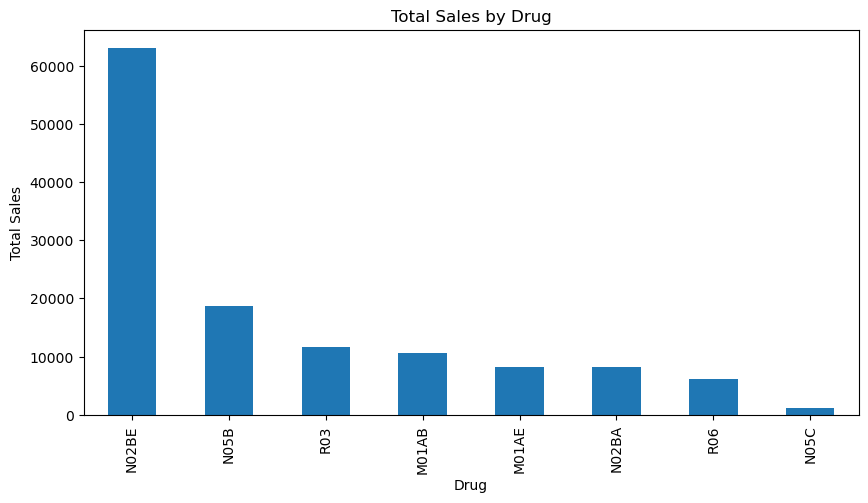

In [11]:
total_sales_by_drug.plot(
    kind='bar',
    title='Total Sales by Drug',
    xlabel='Drug',
    ylabel='Total Sales',
    figsize=(10, 5)
)

In [12]:
df['Total_Sales'] = df[drug_columns].sum(axis=1)

yearly_sales = (
    df.groupby('Year')['Total_Sales']
      .sum()
      .sort_index()
)

yearly_sales

Year
2014    20238.337687
2015    22752.358000
2016    25234.926000
2017    19399.365667
2018    22884.561000
2019    17085.955333
Name: Total_Sales, dtype: float64

<Axes: title={'center': 'Total Pharmaceutical Sales by Year'}, xlabel='Year', ylabel='Total Sales'>

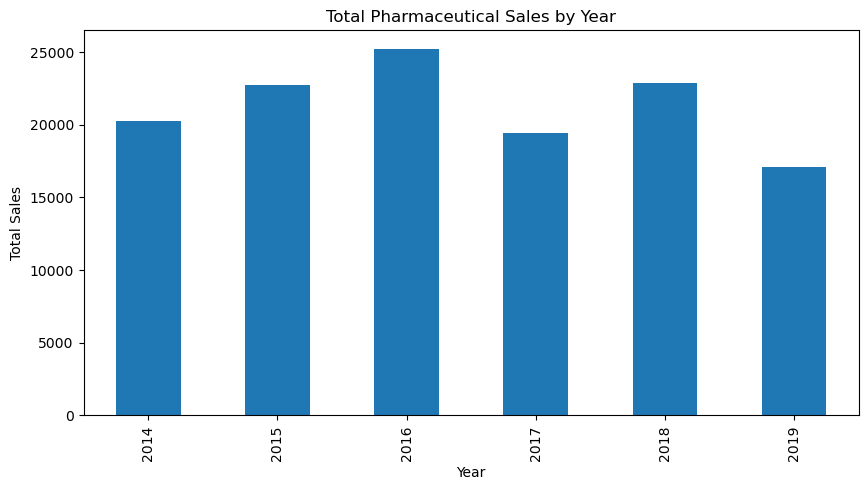

In [13]:
yearly_sales.plot(
    kind='bar',
    title='Total Pharmaceutical Sales by Year',
    xlabel='Year',
    ylabel='Total Sales',
    figsize=(10, 5)
)

In [14]:
monthly_sales = (
    df.groupby('Month')['Total_Sales']
      .sum()
      .sort_index()
)

monthly_sales

Month
1     13970.691083
2     11604.568583
3     11363.605000
4     10248.718000
5      9925.967667
6      8992.861000
7      8758.503333
8      9037.611333
9     11000.856667
10    12051.024687
11     9534.383333
12    11106.713000
Name: Total_Sales, dtype: float64

<Axes: title={'center': 'Total Pharmaceutical Sales by Month'}, xlabel='Month', ylabel='Total Sales'>

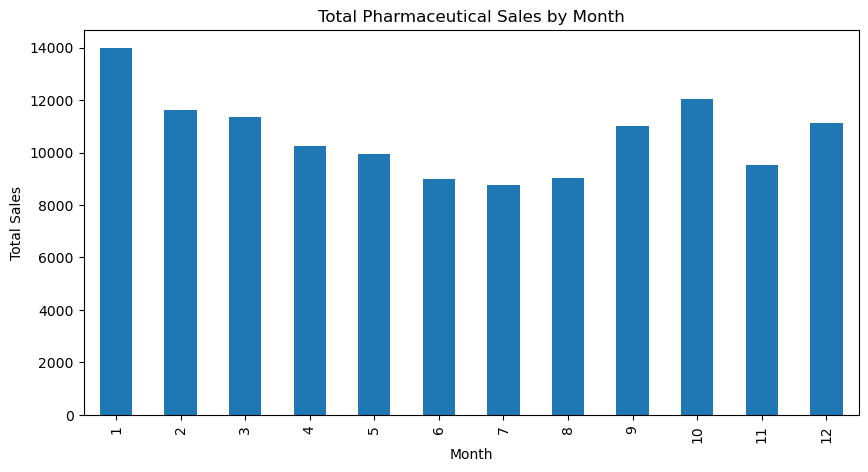

In [15]:
monthly_sales.plot(
    kind='bar',
    title='Total Pharmaceutical Sales by Month',
    xlabel='Month',
    ylabel='Total Sales',
    figsize=(10, 5)
)

In [16]:
hourly_sales = (
    df.groupby('Hour')['Total_Sales']
      .sum()
      .sort_index()
)

hourly_sales

Hour
0         0.000000
1         0.000000
2         0.000000
3         0.000000
4         0.000000
5         0.000000
6         0.000000
7       572.567500
8      6040.749167
9      8094.519667
10     9591.414042
11    10733.956083
12    10546.213542
13     9573.369188
14     8780.673375
15     8186.917917
16     7851.946875
17     8254.304333
18    10071.576917
19    11321.757917
20    11211.060958
21     6603.472458
22      160.420417
23        0.583333
Name: Total_Sales, dtype: float64

<Axes: title={'center': 'Total Pharmaceutical Sales by Hour'}, xlabel='Hour', ylabel='Total Sales'>

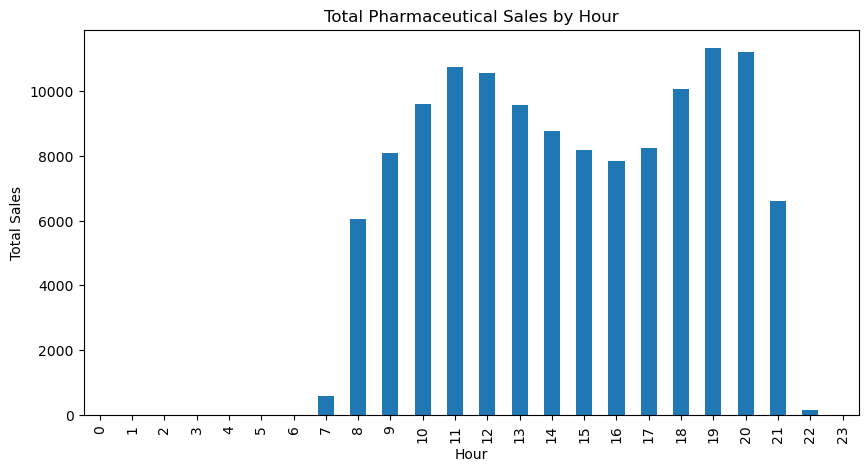

In [17]:
hourly_sales.plot(
    kind='bar',
    title='Total Pharmaceutical Sales by Hour',
    xlabel='Hour',
    ylabel='Total Sales',
    figsize=(10, 5)
)

In [1]:
drug_year_sales = (
    df.groupby('Year')[drug_columns]
      .sum()
)

drug_year_sales

NameError: name 'df' is not defined

In [2]:
import pandas as pd

file_path = r"D:\Data-Analytics-Portfolio\03-Pharmaceutical-Sales-Analytics\Dataset\saleshourly.csv"

df = pd.read_csv(file_path)

df.head()

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,1/2/2014 8:00,0.0,0.67,0.4,2.0,0.0,0.0,0.0,1.0,2014,1,8,Thursday
1,1/2/2014 9:00,0.0,0.00,1.0,0.0,2.0,0.0,0.0,0.0,2014,1,9,Thursday
2,1/2/2014 10:00,0.0,0.00,0.0,3.0,2.0,0.0,0.0,0.0,2014,1,10,Thursday
3,1/2/2014 11:00,0.0,0.00,0.0,2.0,1.0,0.0,0.0,0.0,2014,1,11,Thursday
4,1/2/2014 12:00,0.0,2.00,0.0,5.0,2.0,0.0,0.0,0.0,2014,1,12,Thursday


In [9]:
df['datum'] = pd.to_datetime(df['datum'])

In [10]:
drug_columns = [
    'M01AB',
    'M01AE',
    'N02BA',
    'N02BE',
    'N05B',
    'N05C',
    'R03',
    'R06'
]

In [11]:
df['Total_Sales'] = df[drug_columns].sum(axis=1)

In [12]:
import matplotlib.pyplot as plt

drug_year_sales.plot(
    kind='line',
    marker='o',
    figsize=(12, 6),
    title='Drug Sales Trend by Year'
)

plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.legend(title='Drug')
plt.grid(axis='y', alpha=0.3)
plt.show()

NameError: name 'drug_year_sales' is not defined

In [13]:
drug_year_sales = (
    df.groupby('Year')[drug_columns]
      .sum()
)

drug_year_sales

,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
Year,,,,,,,,
2014,1447.215000,1257.104313,1616.466500,9274.376875,4315.062500,272.625000,1255.000000,800.4875
2015,1895.620000,1496.603000,1608.630000,11923.225000,2965.000000,159.000000,1721.250000,983.0300
2016,2107.285000,1589.441000,1655.216667,13335.580000,3138.333333,207.000000,2137.000000,1065.0700
2017,1846.617083,1387.298333,1288.295833,9258.804833,2555.541667,180.333333,1893.614583,988.8600
2018,1786.930000,1389.656000,1123.800000,11230.925000,3266.200000,235.000000,2655.250000,1196.8000
2019,1517.270000,1084.516000,879.800000,7982.491000,2405.600000,196.000000,1946.708333,1073.5700


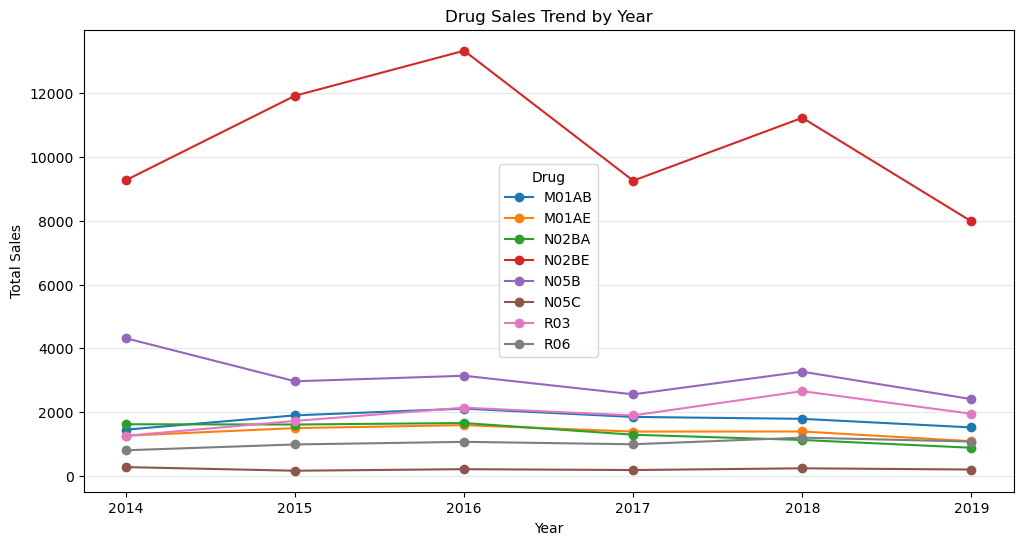

In [14]:
import matplotlib.pyplot as plt

drug_year_sales.plot(
    kind='line',
    marker='o',
    figsize=(12, 6),
    title='Drug Sales Trend by Year'
)

plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.legend(title='Drug')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [15]:
drug_contribution = (
    df[drug_columns]
    .sum()
    .sort_values(ascending=False)
)

drug_contribution_pct = (
    drug_contribution / drug_contribution.sum() * 100
).round(2)

drug_contribution_pct

N02BE    49.38
N05B     14.61
R03       9.10
M01AB     8.31
M01AE     6.43
N02BA     6.40
R06       4.79
N05C      0.98
dtype: float64

In [16]:
pareto = drug_contribution_pct.to_frame(name='Sales_%')

pareto['Cumulative_%'] = pareto['Sales_%'].cumsum()

pareto

,Sales_%,Cumulative_%
N02BE,49.38,49.38
N05B,14.61,63.99
R03,9.10,73.09
M01AB,8.31,81.40
M01AE,6.43,87.83
N02BA,6.40,94.23
R06,4.79,99.02
N05C,0.98,100.00


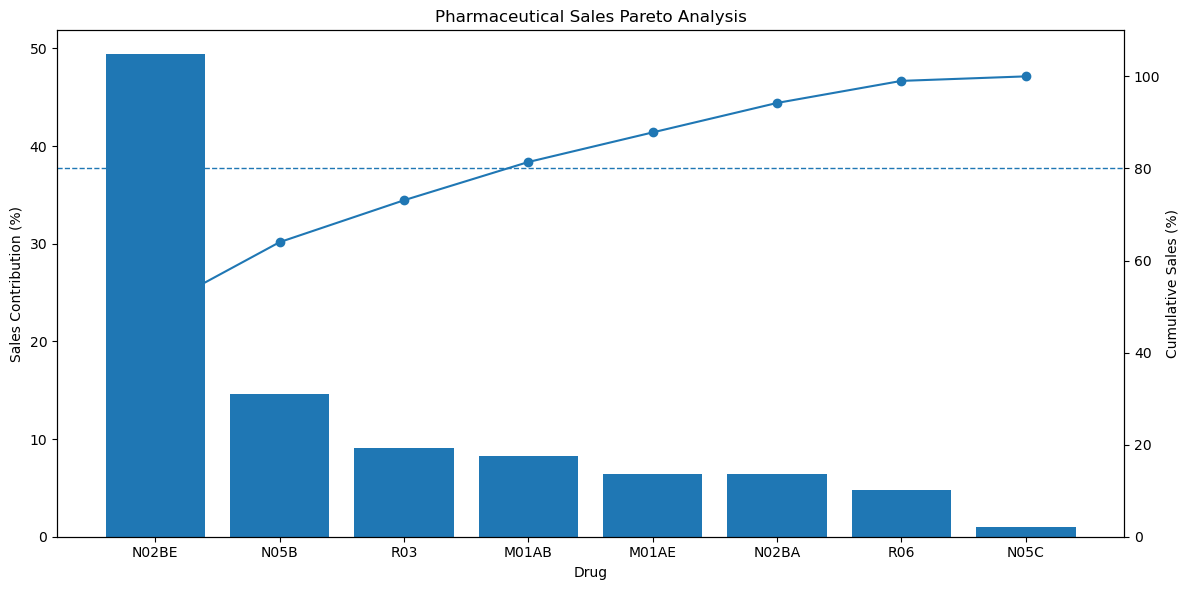

In [17]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12, 6))

# Sales contribution bars
ax1.bar(
    pareto.index,
    pareto['Sales_%']
)

ax1.set_xlabel('Drug')
ax1.set_ylabel('Sales Contribution (%)')
ax1.set_title('Pharmaceutical Sales Pareto Analysis')

# Cumulative percentage line
ax2 = ax1.twinx()

ax2.plot(
    pareto.index,
    pareto['Cumulative_%'],
    marker='o'
)

ax2.set_ylabel('Cumulative Sales (%)')
ax2.set_ylim(0, 110)

# 80% reference line
ax2.axhline(
    80,
    linestyle='--',
    linewidth=1
)

plt.tight_layout()
plt.show()

In [18]:
weekday_sales = (
    df.groupby('Weekday Name')['Total_Sales']
      .sum()
)

weekday_sales

Weekday Name
Friday       18134.491583
Monday       18242.816667
Saturday     19767.594417
Sunday       18401.437250
Thursday     17212.389271
Tuesday      18065.247000
Wednesday    17771.527500
Name: Total_Sales, dtype: float64

In [19]:
weekday_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

weekday_sales = weekday_sales.reindex(weekday_order)

weekday_sales

Weekday Name
Monday       18242.816667
Tuesday      18065.247000
Wednesday    17771.527500
Thursday     17212.389271
Friday       18134.491583
Saturday     19767.594417
Sunday       18401.437250
Name: Total_Sales, dtype: float64

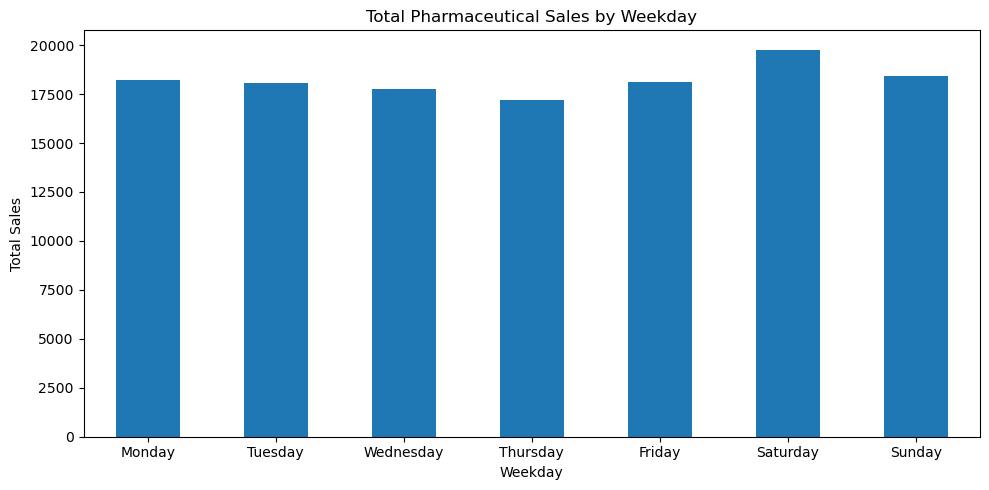

In [20]:
weekday_sales.plot(
    kind='bar',
    figsize=(10, 5),
    title='Total Pharmaceutical Sales by Weekday',
    xlabel='Weekday',
    ylabel='Total Sales'
)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [21]:
weekday_drug_sales = (
    df.groupby('Weekday Name')[drug_columns]
      .sum()
      .reindex(weekday_order)
)

weekday_drug_sales

,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
Weekday Name,,,,,,,,
Monday,1521.776667,1118.503000,1171.765667,8799.013000,2783.316667,185.458333,1791.458333,871.525000
Tuesday,1519.246667,1069.307583,1272.966667,8540.473167,2896.766667,219.166667,1629.197917,918.121667
Wednesday,1439.206667,1110.250000,1131.431667,8422.354167,3037.183333,196.250000,1635.000000,799.851667
Thursday,1369.300000,1092.282396,1110.037500,8478.629375,2623.429167,154.125000,1595.625000,788.960833
Friday,1435.913333,1117.781083,1167.448333,8606.187167,2979.233333,229.500000,1756.041667,842.386667
Saturday,1724.054167,1311.554917,1262.671667,10107.495333,2580.941667,164.750000,1629.666667,986.460000
Sunday,1591.439583,1384.939667,1055.887500,10051.250500,1744.866667,100.708333,1571.833333,900.511667


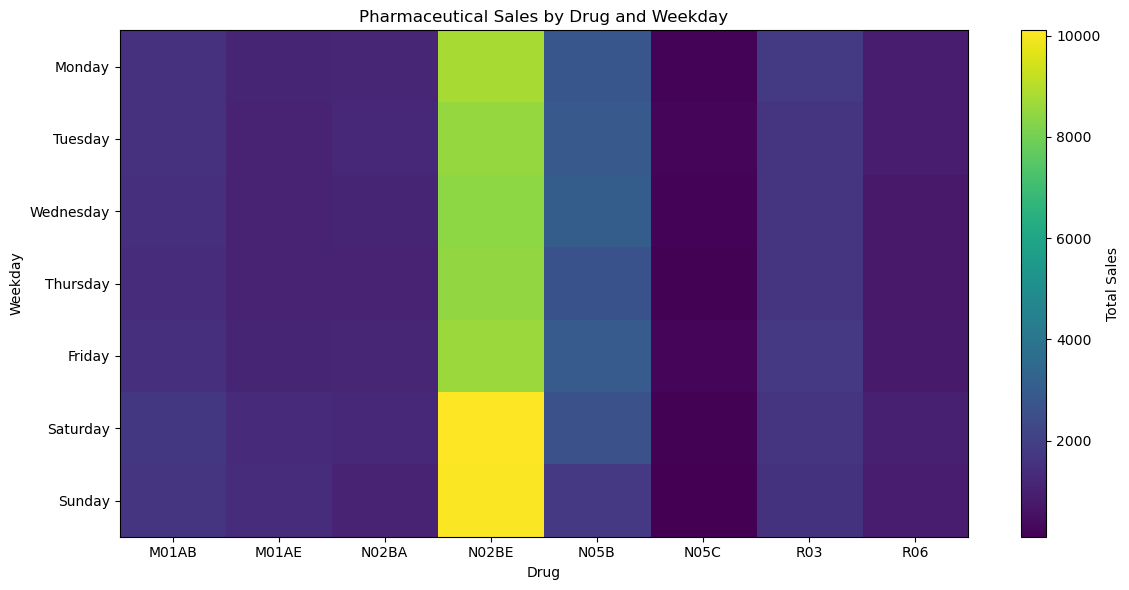

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.imshow(
    weekday_drug_sales,
    aspect='auto'
)

plt.colorbar(label='Total Sales')

plt.xticks(
    range(len(drug_columns)),
    drug_columns
)

plt.yticks(
    range(len(weekday_order)),
    weekday_order
)

plt.xlabel('Drug')
plt.ylabel('Weekday')
plt.title('Pharmaceutical Sales by Drug and Weekday')

plt.tight_layout()
plt.show()